In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("listings.csv")

# View shape and columns
print("Shape:", df.shape)
df.info()


Shape: (459, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            459 non-null    int64  
 1   listing_url                                   459 non-null    object 
 2   scrape_id                                     459 non-null    float64
 3   last_scraped                                  459 non-null    object 
 4   source                                        459 non-null    object 
 5   name                                          459 non-null    object 
 6   description                                   449 non-null    object 
 7   neighborhood_overview                         196 non-null    object 
 8   picture_url                                   459 non-null    object 
 9   host_id                                       45

In [3]:
# Quick look at the first few rows
df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,2.025080e+13,8/4/2025,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,2.025080e+13,8/4/2025,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.81,4.77,NaN,f,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,2.025080e+13,8/4/2025,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.76,4.64,NaN,f,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,2.025080e+13,8/4/2025,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,2.025080e+13,8/4/2025,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,f,1,1,0,0,5.67


In [4]:
# Missing value summary
df.isnull().sum().sort_values(ascending=False).head(20)


license                         459
calendar_updated                459
neighbourhood_group_cleansed    459
neighbourhood                   263
neighborhood_overview           263
host_about                      208
host_location                   114
host_neighbourhood               70
last_review                      68
first_review                     68
review_scores_location           68
review_scores_accuracy           68
reviews_per_month                68
review_scores_value              68
review_scores_cleanliness        68
review_scores_communication      68
review_scores_checkin            68
review_scores_rating             68
beds                             40
bathrooms                        40
dtype: int64

In [9]:
# --- BASIC CLEANING ---

# Drop irrelevant or mostly missing columns
drop_cols = [
    'license', 'calendar_updated', 'neighbourhood', 'neighborhood_overview',
    'host_about', 'host_location', 'host_neighbourhood'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Convert price to numeric
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Convert host_since to datetime
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')

# Convert percentage columns
# Convert percentage columns safely
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')


# Fill numeric columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify cleanup
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            459 non-null    int64         
 1   listing_url                                   459 non-null    object        
 2   scrape_id                                     459 non-null    float64       
 3   last_scraped                                  459 non-null    object        
 4   source                                        459 non-null    object        
 5   name                                          459 non-null    object        
 6   description                                   459 non-null    object        
 7   picture_url                                   459 non-null    object        
 8   host_id                                       459 non-null    int64   

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


Exploratory Data Analysis (EDA)

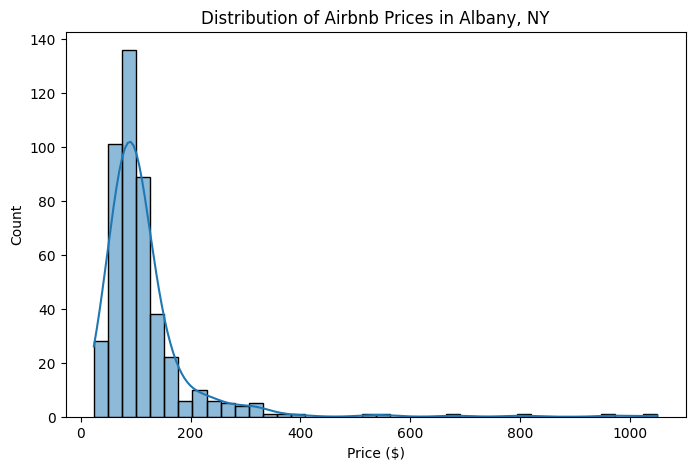

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40, kde=True)
plt.title('Distribution of Airbnb Prices in Albany, NY')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()


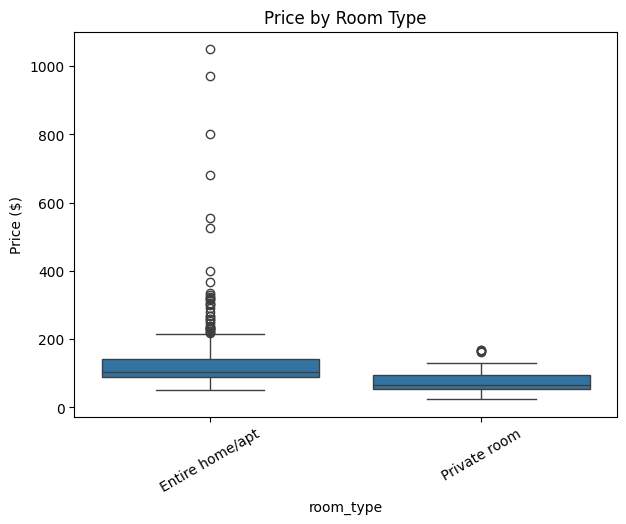

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Price by Room Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=30)
plt.show()


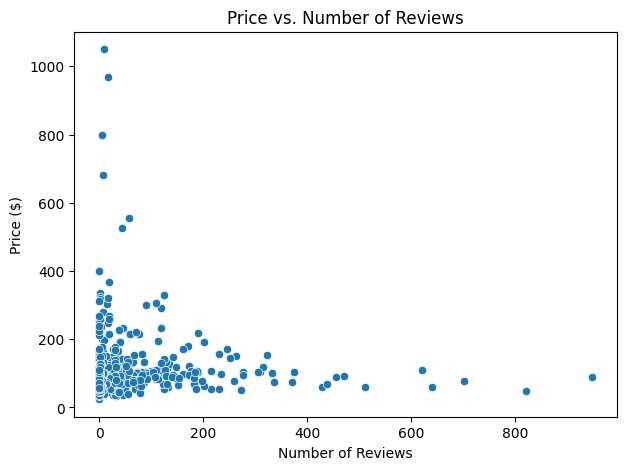

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='number_of_reviews', y='price', data=df)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')
plt.show()



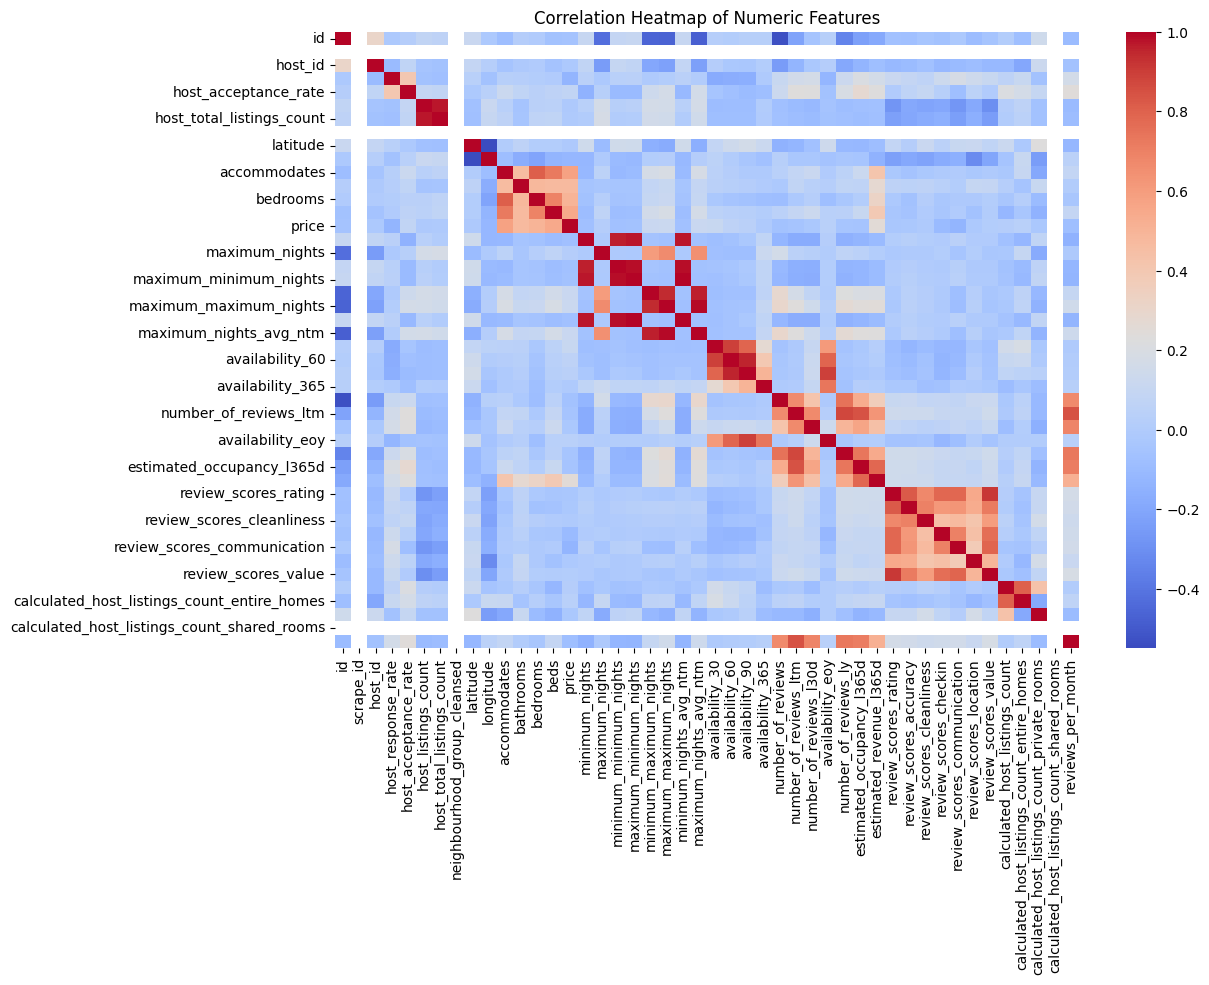

In [14]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()



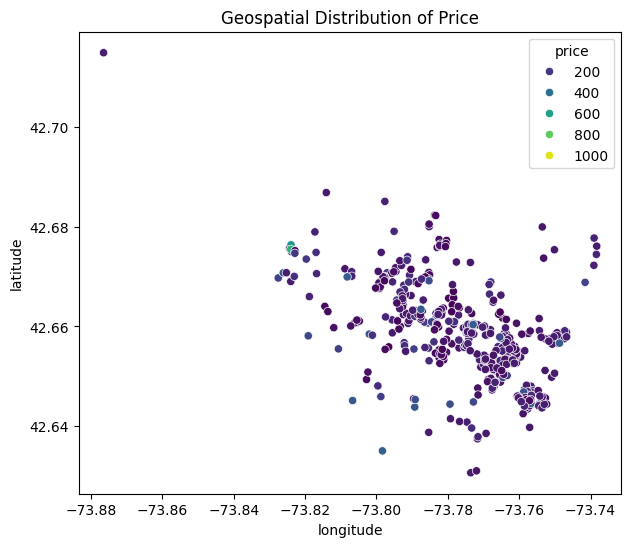

In [15]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='longitude', y='latitude', hue='price', data=df, palette='viridis')
plt.title('Geospatial Distribution of Price')
plt.show()


Feature Engineering

In [17]:
import datetime as dt

today = df['last_scraped'].iloc[0]  # typically same date for all rows
today = pd.to_datetime(today)

df['host_tenure_days'] = (today - df['host_since']).dt.days


In [18]:
df['num_amenities'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)


In [19]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

city_lat, city_lon = 42.6526, -73.7562
df['distance_from_center_km'] = df.apply(
    lambda row: haversine(row['latitude'], row['longitude'], city_lat, city_lon), axis=1
)


In [20]:
df['desc_length'] = df['description'].apply(lambda x: len(str(x).split()))


In [21]:
df[['host_tenure_days', 'num_amenities', 'distance_from_center_km', 'desc_length']].head()


,host_tenure_days,num_amenities,distance_from_center_km,desc_length
0,4592,8,0.622737,27
1,4015,37,0.903855,85
2,3797,33,0.771014,69
3,4015,32,0.903855,81
4,4046,33,0.797202,61


Regression Modeling (Predict Price)

In [22]:
# Select features (you can adjust later)
features = [
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'room_type', 'property_type', 'host_is_superhost',
    'host_tenure_days', 'num_amenities',
    'distance_from_center_km', 'desc_length'
]

target = 'price'

X = df[features].copy()
y = df[target]


In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

X_prepared = preprocessor.fit_transform(X)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42
)


In [26]:
!pip install xgboost

  Using cached xgboost-3.1.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.0-py3-none-win_amd64.whl (72.0 MB)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return mae, rmse, r2

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse')
}

results = {}
for name, model in models.items():
    results[name] = evaluate(model, X_train, y_train, X_test, y_test)

for name, (mae, rmse, r2) in results.items():
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


Linear Regression → MAE: 34.19, RMSE: 57.58, R²: 0.409
Random Forest → MAE: 33.43, RMSE: 72.09, R²: 0.074
XGBoost → MAE: 37.92, RMSE: 96.97, R²: -0.676


In [28]:
import numpy as np

# Transform target variable
y_log = np.log1p(y)

# Re-run Linear Regression with log-transformed price
lr = LinearRegression()
lr.fit(X_train, np.log1p(y_train))
preds = lr.predict(X_test)

# Reverse log for evaluation
preds_exp = np.expm1(preds)
mae = mean_absolute_error(y_test, preds_exp)
rmse = np.sqrt(mean_squared_error(y_test, preds_exp))
r2 = r2_score(y_test, preds_exp)

print(f"After log transform → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")


After log transform → MAE: 28.88, RMSE: 55.67, R²: 0.448


Classification Modeling

In [29]:
median_reviews = df['number_of_reviews'].median()
df['popular'] = (df['number_of_reviews'] > median_reviews).astype(int)

df['popular'].value_counts()


popular
0    239
1    220
Name: count, dtype: int64

In [30]:
features = [
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'room_type', 'property_type', 'host_is_superhost',
    'host_tenure_days', 'num_amenities',
    'distance_from_center_km', 'desc_length'
]

X = df[features]
y = df['popular']


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

X_prepared = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42
)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{name}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))
    print(f"ROC-AUC: {roc_auc_score(y_test, probs):.3f}")


c:\Users\Ahsan\Desktop\Buildables\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
[[38 13]
 [ 9 32]]
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        51
           1       0.71      0.78      0.74        41

    accuracy                           0.76        92
   macro avg       0.76      0.76      0.76        92
weighted avg       0.77      0.76      0.76        92

ROC-AUC: 0.854

Random Forest
[[42  9]
 [ 8 33]]
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        51
           1       0.79      0.80      0.80        41

    accuracy                           0.82        92
   macro avg       0.81      0.81      0.81        92
weighted avg       0.82      0.82      0.82        92

ROC-AUC: 0.902


Classification Summary:
Popularity was defined as listings having more reviews than the dataset median.
Logistic Regression achieved 76% accuracy (ROC-AUC = 0.85), while Random Forest reached 82% accuracy (ROC-AUC = 0.90).
Random Forest therefore provided the best generalization and captured non-linear relationships effectively.
In business terms, a false negative means failing to promote a genuinely popular listing — a higher-cost error than a false positive.
Thus, recall (0.80) is the most important metric for this task.

Deep Learning Experiment (Predict Price with a Neural Network)